# Проверка гипотез в бизнесе
- Автор: Топорова Е.В.
- Дата: 08.04.2026
## Введение
Крупный сервис проката самокатов GoFast предоставил три датасета с данными о пользователях сервиса, их поездках за один год, а также стоимости услуг в подписках. Необходимо проанализировать демографию пользователей и особенности использования самокатов, а также определить возможную выгоду от распространения платной подписки на самокаты.

## Описание данных

Таблица с пользователями `users_go.csv`
- `user_id` — уникальный идентификатор пользователя.
- `name` — имя пользователя.
- `age` — возраст.
- `city` — город.
- `subscription_type` — тип подписки: `free`, `ultra`.

Таблица с поездками `rides_go.csv`
- `user_id` — уникальный идентификатор пользователя.
- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.
- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».
- `date` — дата совершения поездки.

Таблица с подписками `subscriptions_go.csv`
- `subscription_type` — тип подписки.
- `minute_price` — стоимость одной минуты поездки по этой подписке.
- `start_ride_price` — стоимость начала поездки.
- `subscription_fee` — стоимость ежемесячного платежа.

---
## 1 Загрузка данных и знакомство с ними
Загрузим все необходимые библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

Загрузим сами данные.

In [2]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

Выведем первые пять строк каждого датафрейма и познакомимся с содержанием таблиц.

In [3]:
display(df_users_go.head())
display(df_rides_go.head())
display(df_subscriptions_go.head())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Определим количество строк в каждом из трёх датафреймов. Это поможет оценить объём данных и выявить аномалии, например, слишком малое количество записей.

In [4]:
print(df_users_go.shape[0], df_rides_go.shape[0], df_subscriptions_go.shape[0])

1565 18068 2


---
## 2 Предобработка данных

В датафрейме `df_rides_go` выведем типы данных каждой колонки.

In [5]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

Приведем столбец `date` в датафрейме `df_rides_go` к типу даты.

In [6]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

На основе столбца `date` создадим новый столбец `month`, содержащий номер месяца. Это нужно для последующей группировки данных и анализа сезонных трендов.

In [7]:
df_rides_go['month'] = df_rides_go['date'].dt.month

В датафрейме пользователей `df_users_go` определим количество пропусков и дубликатов.

In [8]:
print(df_users_go.isna().sum().sum(), sum(df_users_go.duplicated()))

0 31


Пропуски отсутствуют, а вот дубликаты в данных есть, удалим их.

In [9]:
df_users_go = df_users_go.drop_duplicates()

В датафрейме поездок `df_rides_go` приведем `duration` к целочисленному типу int. Это поможет правильно рассчитать прибыль, так как плата взимается только за целое число минут.

In [10]:
df_rides_go['duration'] = round(df_rides_go['duration']).astype('int')

---
## 3 Исследовательский анализ данных (EDA)
### 3.1 Количество пользователей по городам
Пользуясь данными из датафрейма `df_users_go`, изучим количество пользователей в каждом из городов.

In [11]:
users_by_city_count = df_users_go['city'].value_counts()

print(users_by_city_count)

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


### 3.2 Количество пользователей подписки
Посчитаем количество пользователей для каждого типа подписки `subscription_type`.

In [12]:
subscription_type_count = df_users_go.merge(df_subscriptions_go, on='subscription_type')['subscription_type'].value_counts()
subscription_type_count

free     835
ultra    699
Name: subscription_type, dtype: int64

Построим круговую диаграмму, указав процент пользователей с `free` и `ultra` подпиской.

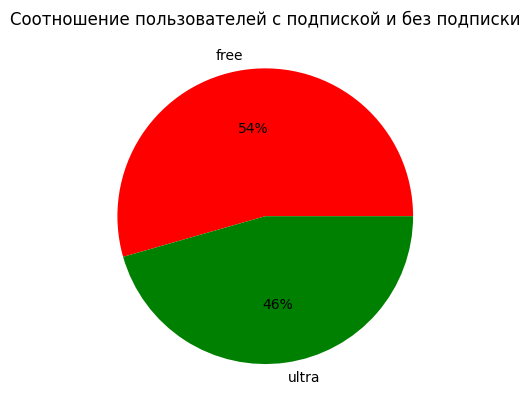

In [13]:
subscription_type_count.plot(
    kind='pie',
    title='Соотношение пользователей с подпиской и без подписки',
    autopct='%.0f%%',
    ylabel='',
    colors=['red', 'green']
)

plt.show()

### 3.3 Гистограмма возрастов

Построим гистограмму возрастов `age` пользователей самокатов. 

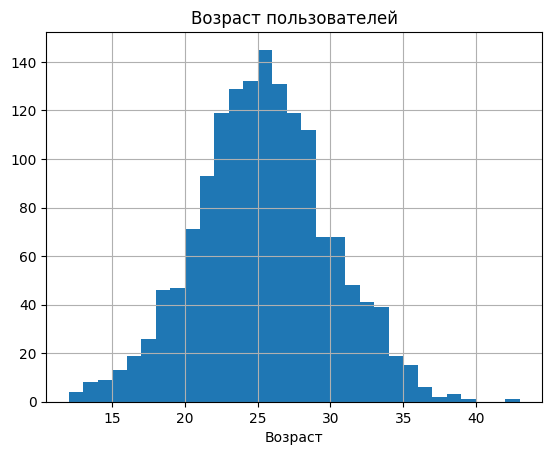

In [14]:
n_bins = df_users_go['age'].max() - df_users_go['age'].min()
df_users_go['age'].hist(bins=n_bins)
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.show()

### 3.4 Несовершеннолетние пользователи
Рассчитаем долю несовершеннолетних (возрастом менее 18 лет) пользователей самокатов.

In [15]:
users_under_18_ratio = round(df_users_go[df_users_go['age'] < 18].shape[0] / df_users_go['age'].shape[0] * 100)
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


### 3.5 Характеристики длительности поездки
Длительность поездки является важной метрикой в работе сервиса проката самокатов. Если средняя длительность поездок будет слишком высокой, самокаты будут быстрее выходить из строя. Если слишком низкой, значит, клиентам что-то не нравится в сервисе. Поэтому изучим данную метрику.

In [16]:
duration_mean = round(df_rides_go['duration'].mean())
duration_std = round(df_rides_go['duration'].std())

duration_pct25 = round(df_rides_go['duration'].quantile(0.25))
duration_pct75 = round(df_rides_go['duration'].quantile(0.75))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


---
## 4 Объединение данных
Объединим датафреймы с информацией о пользователях `df_users_go` и поездках `df_rides_go`.

In [17]:
df = df_users_go.merge(df_rides_go, on='user_id', how='left')

Присоединим к полученному датафрейму `df` информацию о подписках из `df_subscriptions_go`.

In [18]:
df = df.merge(df_subscriptions_go, on='subscription_type', how='left')

Для финальной проверки выведем на экран первые пять строк датафрейма, а также количество строк и столбцов полученного датафрейма `df`. Этот этап позволит убедиться, что никакие записи не потерялись при объединении.

In [19]:
display(df.head())
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


### 4.1 Отдельные датафреймы для пользователей с подпиской и без
Создадим также два вспомогательных датафрейма на основе `df`: первый только для пользователей с подпиской `df_ultra` и второй только для пользователей без подписки `df_free`. В следующих заданиях два этих датафрейма пригодятся при изучении поведения пользователей с подпиской и без, а также при проверке продуктовых гипотез.

In [20]:
df_ultra = df[df['subscription_type'] == 'ultra']
df_free = df[df['subscription_type'] == 'free']

### 4.2 Гистограмма длительности поездок для обоих групп
Построим гистограмму распределения длительности поездок `duration` для пользователей с подпиской и без.

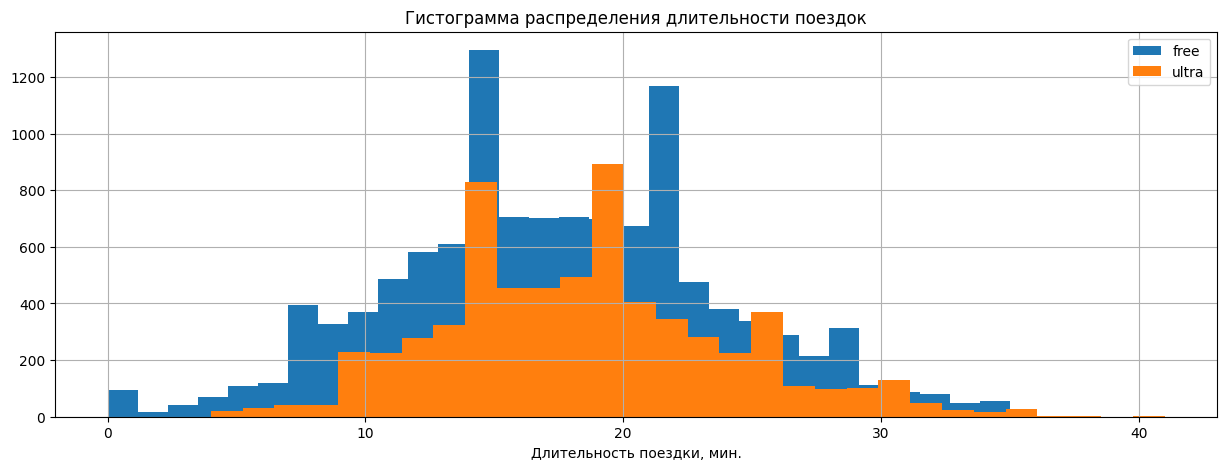

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [21]:
plt.figure(figsize=(15, 5))
df_free['duration'].hist(bins=30, label='free')
df_ultra['duration'].hist(bins=30, label='ultra')
plt.xlabel('Длительность поездки, мин.')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()
plt.show()

mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

---
## 5 Подсчёт выручки
Сгруппируем данные по следующим столбцам: `user_id`, `name`, `subscription_type`, `month`.

In [22]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

Создадим новый датафрейм `df_agg`. В нём для каждой группы рассчитаем и добавим в датафрейм следующие агрегированные значения:
- `total_distance` — сумма значений в столбце `distance`.
- `total_duration` — сумма значений в столбце `duration`.
- `rides_count` — количество элементов в столбце `duration`.
- `subscription_type` — первое значение в группе для столбца `subscription_type`.
- `minute_price` — первое значение в группе для столбца `minute_price`.
- `start_ride_price` — первое значение в группе для столбца `start_ride_price`.
- `subscription_fee` — первое значение в группе для столбца `subscription_fee`.

In [23]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first'),
)

Создадим функцию `calculate_monthly_revenue(row)` для расчёта месячной выручки по формуле:

`monthly_revenue` = `start_ride_price` * `rides_count` + `minute_price` * `total_duration` + `subscription_fee`
 
Здесь:
- `start_ride_price * rides_count` — выручка от начала каждой поездки.
- `minute_price * total_duration` — выручка за время использования.
- `subscription_fee` — фиксированная выручка от подписок.

In [24]:
def calculate_monthly_revenue(row):
    monthly_revenue = row['start_ride_price'] * row['rides_count'] + row['minute_price'] * row['total_duration'] + row['subscription_fee']
    return monthly_revenue

Создадим новый столбец с месячной выручкой на пользователя `monthly_revenue`. Для этого применим функцию `calculate_monthly_revenue(row)` к каждой строке агрегированного датафрейма `df_agg`.

In [25]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

Исследуем полученные значения выручки. Найдем пользователя с максимальной суммарной выручкой за весь период наблюдения и выведем информацию о нем.

In [26]:
user_total_revenue = df_agg.groupby('user_id')['monthly_revenue'].sum()
top_user = user_total_revenue.idxmax()

df_agg[df_agg['user_id'] == top_user][['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']]

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


---
## 6 Проверка гипотез
### 6.1 Вспомогательная функция для интерпретации результатов
Напишем вспомогательную функцию `print_stattest_results(p_value, alpha)`, которая будет интерпретировать результаты статистического теста на основе p-value и заданного уровня значимости (α-уровня). Функция должна решать, следует ли принять альтернативную гипотезу или сохранить нулевую гипотезу.

У функции два параметра:
- `p_value` (тип `float`) — значение p-value, полученное в результате выполнения статистического теста.
- `alpha` (тип `float`, необязательный, по умолчанию `alpha = 0.05`) — уровень значимости статистического теста, который используется как порог для принятия решения об отклонении нулевой гипотезы.


In [27]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value <= alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.2 Длительность для пользователей с подпиской и без
Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Среднее время поездки у пользователей с подпиской и без подписки одинаковое.
- Альтернативная гипотеза (Н1): Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

In [28]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)
ultra_mean_duration = round(ultra_duration.mean(), 2)
free_mean_duration = round(free_duration.mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


### 6.3 Длительность поездки: больше или меньше критического значения
Проанализируем ещё одну важную продуктовую гипотезу. Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, меньше 3130 метров?

Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Средняя дистанция поездки у пользователей с подпиской равна 3130 м.
- Альтернативная гипотеза (Н1): Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

In [29]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.4 Прибыль от пользователей с подпиской и без
Проверим гипотезу о том, что выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.
- Альтернативная гипотеза (Н1): Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.


In [30]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


---
## 7 Распределения
В компании возникла идея предлагать дополнительную скидку подписчикам, совершающим длительные поездки продолжительностью более 30 минут. Необходимо оценить долю таких поездок. Учитывая, что у нас нет доступа ко всем данным о поездках, было решено смоделировать длительность поездки с помощью нормального распределения, используя в качестве параметров выборочное среднее и стандартное отклонение из доступных данных о поездках.

### 7.1 Расчёт выборочного среднего и стандартного отклонения

In [31]:
mu = df_ultra['duration'].mean()
sigma = df_ultra['duration'].std()
# Задаём целевое время
target_time = 30
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


Если вычислить значение функции распределения в точке, это позволит узнать вероятность того, что случайная величина примет значение меньше заданного либо равное ему. Соответственно, если мы хотим ответить на вопрос о вероятности поездки более 30 минут, потребуется использовать CDF.

In [32]:
duration_norm_dist  = st.norm(mu, sigma)
prob = round(1 - duration_norm_dist.cdf(target_time), 3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


Коллеги посчитали, что процент пользователей, для которых будет показана скидка, недостаточно большой и вряд ли поможет в увеличении лояльности клиентов. Дополнительно необходимо проверить, какой процент пользователей совершает поездки в интервале от 20 до 30 минут. Возможно, именно для них стоит провести промоакцию?

In [33]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


Длительные поездки могут негативно сказываться на сроке службы самоката. В связи с этим принято решение установить критическую дистанцию, превышение которой будет сопровождаться дополнительной платой. Для этого необходимо определить расстояние, которое превышается только в 10% поездок (90-й процентиль).

In [34]:
mu = df['distance'].mean()
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.9

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


## 8 Итоговый вывод

1. Пользователи с платной подпиской `ultra` в среднем ездят дольше, чем пользователи с бесплатным тарифом `free`. Статистический тест подтвердил, что разница в длительности поездок значима.
2. Средняя дистанция поездки пользователей с подпиской не превышает 3130 метров, что является оптимальным значением с точки зрения износа самокатов. Гипотезу о превышении этого порога отклонить не удалось.
3. Распределение возрастов пользователей: большая часть сосредоточена в диапазоне примерно от 20 до 35 лет. Доля несовершеннолетних (до 18 лет) составляет 5%.
4. Выручка от пользователей с подпиской `ultra` статистически значимо выше, чем от пользователей с бесплатным тарифом. Средняя месячная выручка у `ultra` составила 359 руб., у `free` — 322 руб. Это подтверждает, что распространение платной подписки является выгодным для компании.

### Рекомендации:
- Вероятность поездки дольше 30 минут (для скидки) составляет всего около 2%, что очень мало. Стимулировать лояльность через длительные поездки неэффективно.
- Вероятность поездки продолжительностью от 20 до 30 минут составляет ~38% (более трети поездок). Эта группа пользователей может быть более подходящей для проведения промо-акций.
- Чтобы взимать дополнительную плату за слишком длинные поездки, порог следует установить на уровне ~4500 метров. Только 10% поездок превышают это расстояние.